In [1]:
# General
import numpy as np

# Qiskit imports
from qiskit import QuantumCircuit,  ClassicalRegister, QuantumRegister
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import SamplerV2 as Sampler

# Qiskit Runtime imports
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator

# Plotting routines
import matplotlib.pyplot as plt
import matplotlib.ticker as tck
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
import qiskit_aer.noise as noise
from qiskit import QuantumCircuit, transpile
from qiskit import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit.transpiler.passes import ALAPScheduleAnalysis
from qiskit.transpiler import PassManager
import csv
from qiskit.visualization import plot_histogram, plot_distribution


In [2]:
## Save your IBM Quantum account and set it as your default account.
your_api_key = "9hJ2tQCPO5ZQfbTqHZJ9MVvWw_VIcdVf-PSrSRU2A9Sx"
your_crn = "crn:v1:bluemix:public:quantum-computing:us-east:a/5e68d80097b441d1a02d32bf585bedac:6ef82fed-0a87-4949-a472-bfa604ffc372::"

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=your_api_key,
    instance=your_crn,
    name="Surface_Code",
    overwrite=True
)
service = QiskitRuntimeService(channel="ibm_quantum_platform")
backend = AerSimulator()

In [19]:
# backend_properties = backend.properties(backend)


In [3]:
# scot qreg 
def split_surface(backend):
    qreg = QuantumRegister(28, 'q')
    creg = ClassicalRegister(28, 'c')

    qc = QuantumCircuit(qreg, creg)


    qc.cx(1, 0)
    qc.cx(27, 0)

    qc.cx(1, 2)
    qc.cx(3, 2)

    qc.cx(3, 4)
    qc.cx(5, 4)

    qc.cx(5, 6)
    qc.cx(7, 6)

    qc.cx(7, 8)
    qc.cx(9, 8)

    qc.cx(9, 10)
    qc.cx(11, 10)

    qc.cx(11, 12)
    qc.cx(13, 12)

    qc.cx(13, 14)
    qc.cx(15, 14)

    qc.cx(15, 16)
    qc.cx(17, 16)

    qc.cx(17, 18)
    qc.cx(19, 18)

    qc.cx(19, 20)
    qc.cx(21, 20)

    qc.cx(21, 22)
    qc.cx(23, 22)

    qc.cx(23, 24)
    qc.cx(25, 24)

    qc.cx(25, 26)
    qc.cx(27, 26)


    qc.barrier()
    for i in range(28):
        qc.measure(i, i)
    
    display (qc.draw('mpl'))

    # layout = list(range(13))  # [0, 1, ..., 12]
    # layout.append(17)         # add 17
    # layout.extend(range(30, 17, -1))  # add [30, 29, ..., 18]
    # layout.append(14)         # add 14
    # print(layout)

    # transpiled_qc1 = pass_manager.run(qc)
    # display( transpiled_qc1.draw("mpl") )
    
    return qc

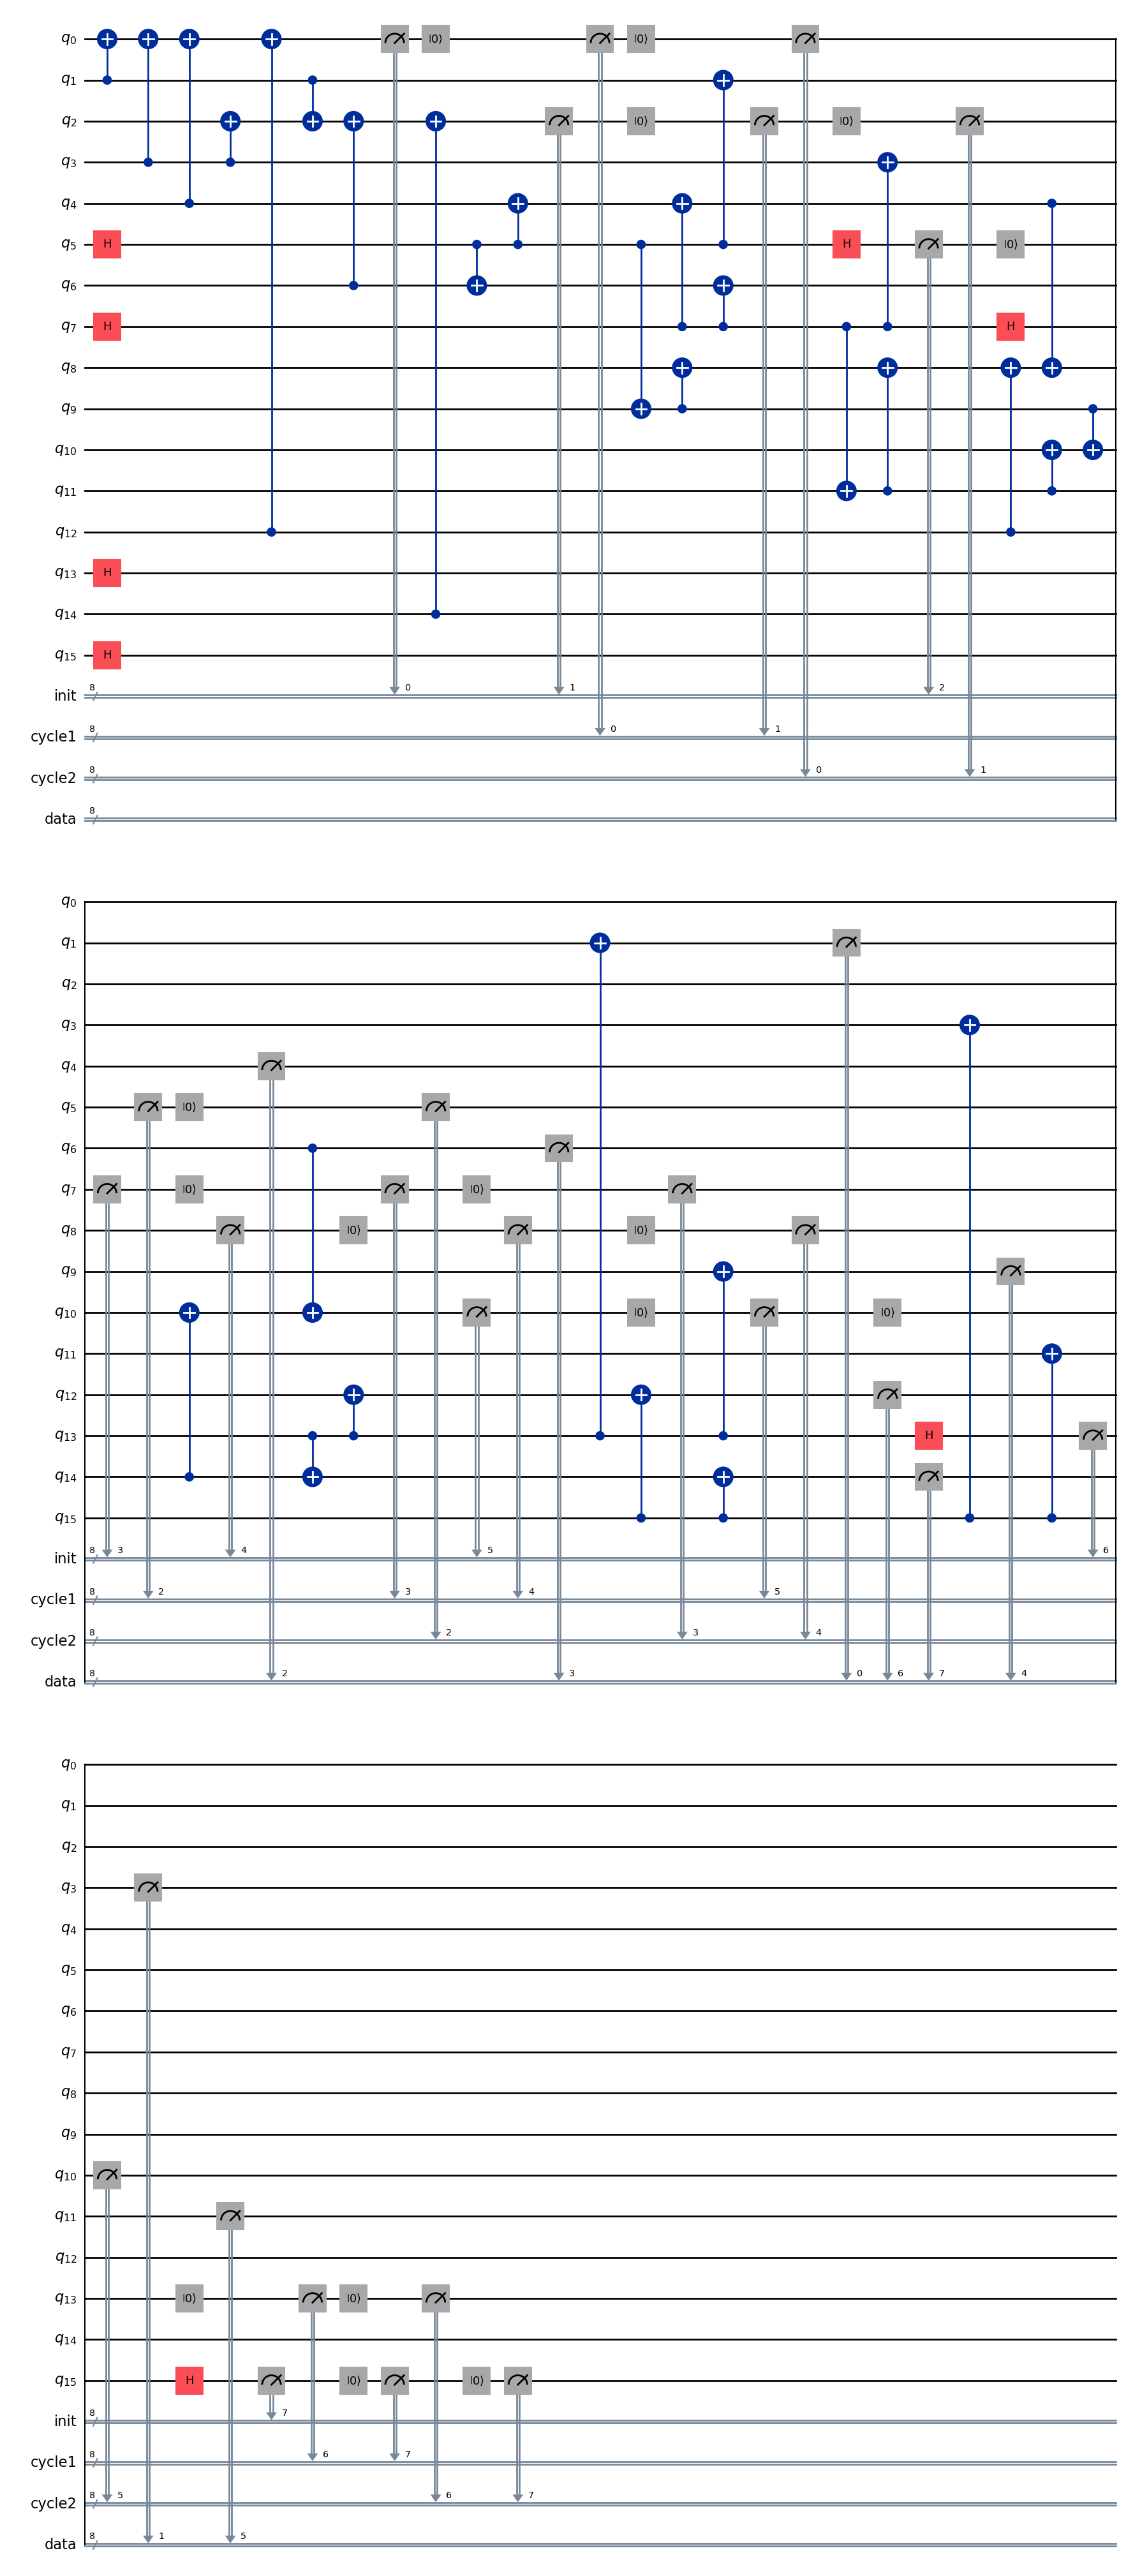

In [2]:
# finalQc = split_surface(backend)
from GridCreator import GridCreator

finalQc = GridCreator.createGrid(2, 2)
# finalQc.measure_all()

display (finalQc.draw('mpl'))

In [ ]:
noise_model = NoiseModel()

two_qubit_error = noise.depolarizing_error(0.001,2) 
noise_model.add_all_qubit_quantum_error(two_qubit_error,['cx'])


# noise_model = NoiseModel.from_backend(service.backend("ibm_brisbane"))


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7daf20b9ed10>>
Traceback (most recent call last):
  File "/home/stefan/Stefan Projects/qiskit_SummerSchool/qgss-2025/lab-0/.venv/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


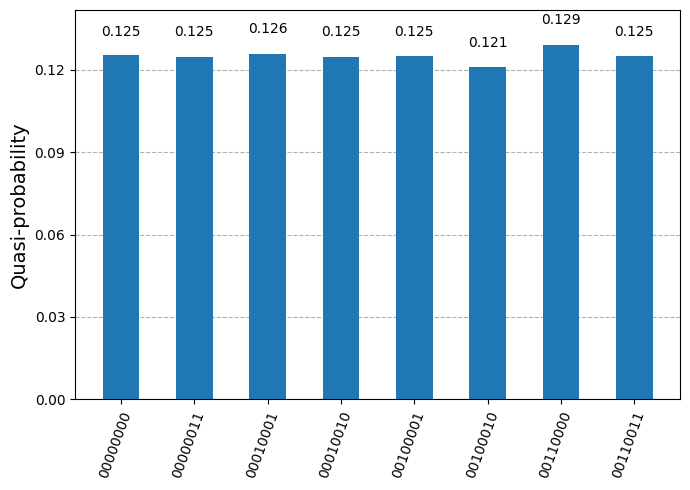

In [3]:

backend = AerSimulator()

transpiled_circ = transpile(finalQc, backend)

job = backend.run(transpiled_circ, shots=10000)
result = job.result()

counts = result.get_counts()

init_counts = {}

# print(counts)

for key, val in counts.items():
    reversed_key = key[::-1]
    init = reversed_key[0:8]
    init_counts[init] = init_counts.get(init, 0) + val

plot_distribution(init_counts)   


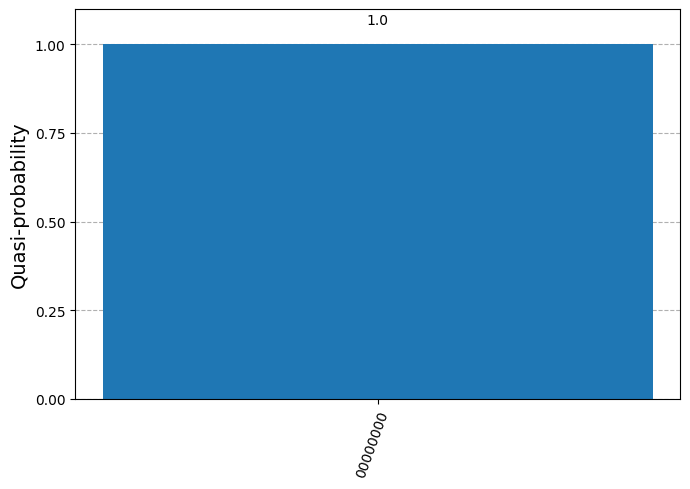

In [4]:
second_round_counts = {}

for key, val in counts.items():
    reversed_key = key[::-1]
    second_round = reversed_key[9:17] 
    second_round_counts[second_round] = second_round_counts.get(second_round, 0) + val

plot_distribution(second_round_counts)

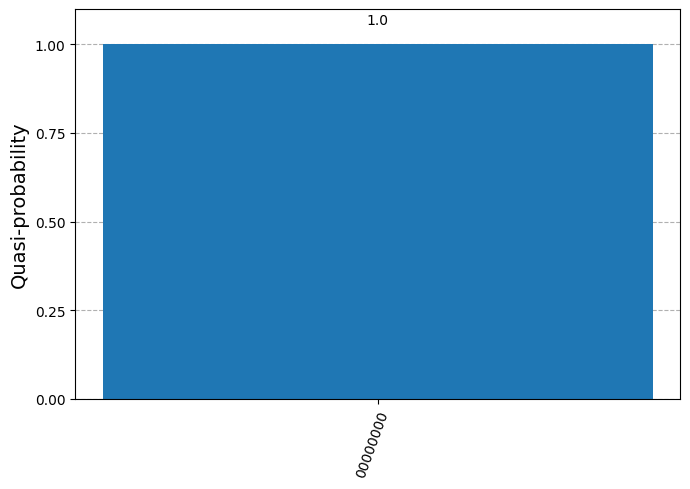

In [5]:
third_round_counts = {}

for key, val in counts.items():
    reversed_key = key[::-1]
    third_round = reversed_key[18:26] 
    third_round_counts[third_round] = third_round_counts.get(third_round, 0) + val

plot_distribution(third_round_counts)

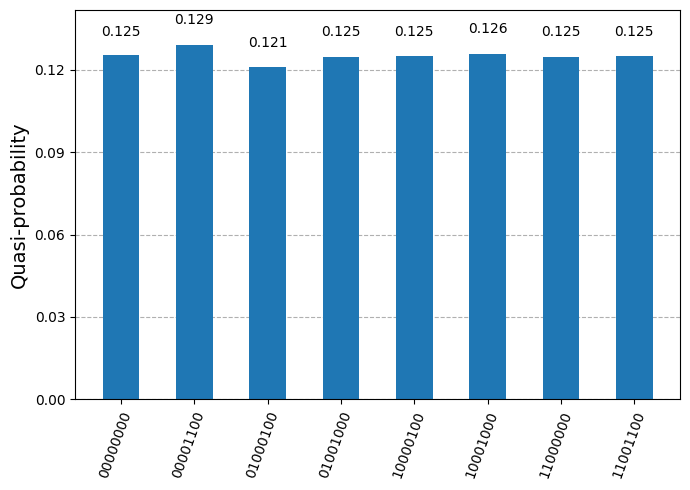

In [6]:
data_counts = {}

for key, val in counts.items():
    reversed_key = key[::-1]
    data = key[27:35]  
    data_counts[data] = data_counts.get(data, 0) + val

plot_distribution(data_counts)